# Продуктовая структура и кредитный риск синтетического розничного портфеля

Как рост долей потребительских кредитов, автокредитов или кредитных карт за счёт ипотеки влияет на потери и финансовый результат? Главные результаты — эффект +1 процентного пункта доли и критическая доля при RAFR = 0.

Данные → Base → стресс стоимости риска → три независимых эксперимента с составом → обратное стресс-тестирование.

## Данные и метод

Единственный вход — `dataset_vtb_main_clean.xlsx`, лист `DATA_MASTER`. Четыре продукта, Base на 30.06.2026, горизонт 2026H2 = 0,5 года. Экспозиция портфеля получается суммированием Excel.

`credit_cost = 2 × ECL_remeasurement / average_exposure`; `ECL_rate = reserve / exposure` — отдельный показатель запаса. CC является исследовательским потоковым показателем, а не официальным продуктовым CoR ВТБ.

CRAS (credit-risk-adjusted spread — спред с учётом риска) = pricing − funding − CC. RAFR (risk-adjusted financial result — финансовый результат с учётом риска) = exposure × CRAS × 0,5. Кредитные потери = exposure × CC × 0,5.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import Markdown, Image, display

root = Path.cwd()
if not (root / 'src').exists():
    root = root.parent
sys.path.insert(0, str(root / 'src'))
import stress_model as sm

cfg = sm.load_config(root / 'config/model_config.json')
files = sm.run_model(root / 'config/model_config.json')
baseline = pd.read_csv(files['baseline_summary'])
summary = pd.read_csv(files['scenario_summary'])
mix = pd.read_csv(files['product_mix_summary'])
qa = pd.read_csv(files['qa'])


## Базовый портфель

Ипотечный proxy 17,8% — внешняя ставка по рыночной ипотеке Банка России за июнь 2026; она не является фактической доходностью ВТБ. Исходный смешанный borrower-side proxy 9,0% сохранён в Excel и отдельной чувствительности. Другие ставки по кредитам и фондированию берутся из того же Excel.

In [2]:
display(Markdown(sm.presentation_table(
    baseline, rates=['weight', 'pricing', 'funding', 'credit_cost', 'cras'],
    labels={'product': 'Продукт', 'exposure': 'Экспозиция, млрд руб.', 'weight': 'Доля',
            'pricing': 'Ставка', 'funding': 'Фондирование', 'credit_cost': 'Стоимость риска',
            'cras': 'CRAS', 'credit_loss_bn': 'Потери за 6М', 'raf_result_bn': 'RAFR за 6М'})))
display(Markdown(f"Общая экспозиция: **{baseline.exposure.sum():,.1f} млрд руб.**"))

| Продукт                 |   Экспозиция, млрд руб. | Доля   | Ставка   | Фондирование   | Стоимость риска   | CRAS   |   Потери за 6М |   RAFR за 6М |
|:------------------------|------------------------:|:-------|:---------|:---------------|:------------------|:-------|---------------:|-------------:|
| Ипотека                 |                4279.800 | 65.11% | 17.80%   | 10.90%         | 0.68%             | 6.22%  |         14.555 |      133.098 |
| Потребительские кредиты |                1525.900 | 23.21% | 17.50%   | 10.90%         | 4.25%             | 2.35%  |         32.436 |       17.918 |
| Автокредиты             |                 543.900 | 8.27%  | 16.50%   | 10.90%         | 4.35%             | 1.25%  |         11.817 |        3.412 |
| Кредитные карты         |                 223.400 | 3.40%  | 31.20%   | 13.00%         | 5.59%             | 12.61% |          6.244 |       14.086 |

Общая экспозиция: **6,573.0 млрд руб.**

## Base / Moderate / Severe

Состояния отличаются только стоимостью риска. Множители 1 / 1,5 / 2 — предварительные MODEL ASSUMPTION (модельные предположения), которые не оценены статистически. Pricing, funding и исходная структура одинаковы. Полугодовая история не используется для sigma-калибровки.

In [3]:
display(Markdown(sm.presentation_table(
    summary, rates=['cras'], labels={'scenario': 'Сценарий', 'credit_loss_bn': 'Потери, млрд руб.',
                                   'raf_result_bn': 'RAFR, млрд руб.', 'cras': 'CRAS'})))

| Сценарий   |   Потери, млрд руб. |   RAFR, млрд руб. | CRAS   |
|:-----------|--------------------:|------------------:|:-------|
| Базовый    |              65.053 |           168.514 | 5.13%  |
| Умеренный  |              97.579 |           135.987 | 4.14%  |
| Тяжёлый    |             130.106 |           103.461 | 3.15%  |

## Предельные эффекты и критические доли

В каждом из трёх экспериментов растёт только выбранный продукт за счёт ипотеки; две остальные доли фиксированы. Шаг сетки — 0,1 п.п., от текущей доли до полного замещения ипотеки.

ΔRAFR на +1 п.п. = total × 0,5 × 0,01 × (CRAS_target − CRAS_Mortgage).

Δпотери на +1 п.п. = total × 0,5 × 0,01 × (CC_target − CC_Mortgage).

Порог решается аналитически и сверяется с сеткой. NA означает отсутствие первого допустимого пересечения или уже достигнутую исходную границу — причина отражена в статусе.

In [4]:
display(Markdown(sm.presentation_table(
    mix, rates=['baseline_share', 'critical_share'],
    labels={'product': 'Продукт', 'scenario': 'Сценарий', 'baseline_share': 'Исходная доля',
            'delta_raf_result_per_1pp': 'ΔRAFR на +1 п.п., млрд руб.',
            'delta_credit_loss_per_1pp': 'Δпотери на +1 п.п., млрд руб.',
            'critical_share': 'Критическая доля', 'status': 'Статус'})))

| Продукт                 | Сценарий   | Исходная доля   |   ΔRAFR на +1 п.п., млрд руб. |   Δпотери на +1 п.п., млрд руб. | Критическая доля   | Статус                            |
|:------------------------|:-----------|:----------------|------------------------------:|--------------------------------:|:-------------------|:----------------------------------|
| Потребительские кредиты | Базовый    | 23.21%          |                        -1.272 |                           1.174 | NA                 | Нет порога в допустимом диапазоне |
| Потребительские кредиты | Умеренный  | 23.21%          |                        -1.859 |                           1.761 | NA                 | Нет порога в допустимом диапазоне |
| Потребительские кредиты | Тяжёлый    | 23.21%          |                        -2.446 |                           2.347 | 65.51%             | Порог существует                  |
| Автокредиты             | Базовый    | 8.27%           |                        -1.632 |                           1.205 | NA                 | Нет порога в допустимом диапазоне |
| Автокредиты             | Умеренный  | 8.27%           |                        -2.234 |                           1.807 | 69.14%             | Порог существует                  |
| Автокредиты             | Тяжёлый    | 8.27%           |                        -2.836 |                           2.409 | 44.75%             | Порог существует                  |
| Кредитные карты         | Базовый    | 3.40%           |                         2.100 |                           1.613 | NA                 | Нет порога в допустимом диапазоне |
| Кредитные карты         | Умеренный  | 3.40%           |                         1.293 |                           2.420 | NA                 | Нет порога в допустимом диапазоне |
| Кредитные карты         | Тяжёлый    | 3.40%           |                         0.487 |                           3.227 | NA                 | Нет порога в допустимом диапазоне |

## Три независимых эксперимента

Вертикальная пунктирная линия показывает исходную долю. Точки на нулевой горизонтали — существующие критические доли. Отсутствие точки является допустимым результатом.

### Потребительские кредиты

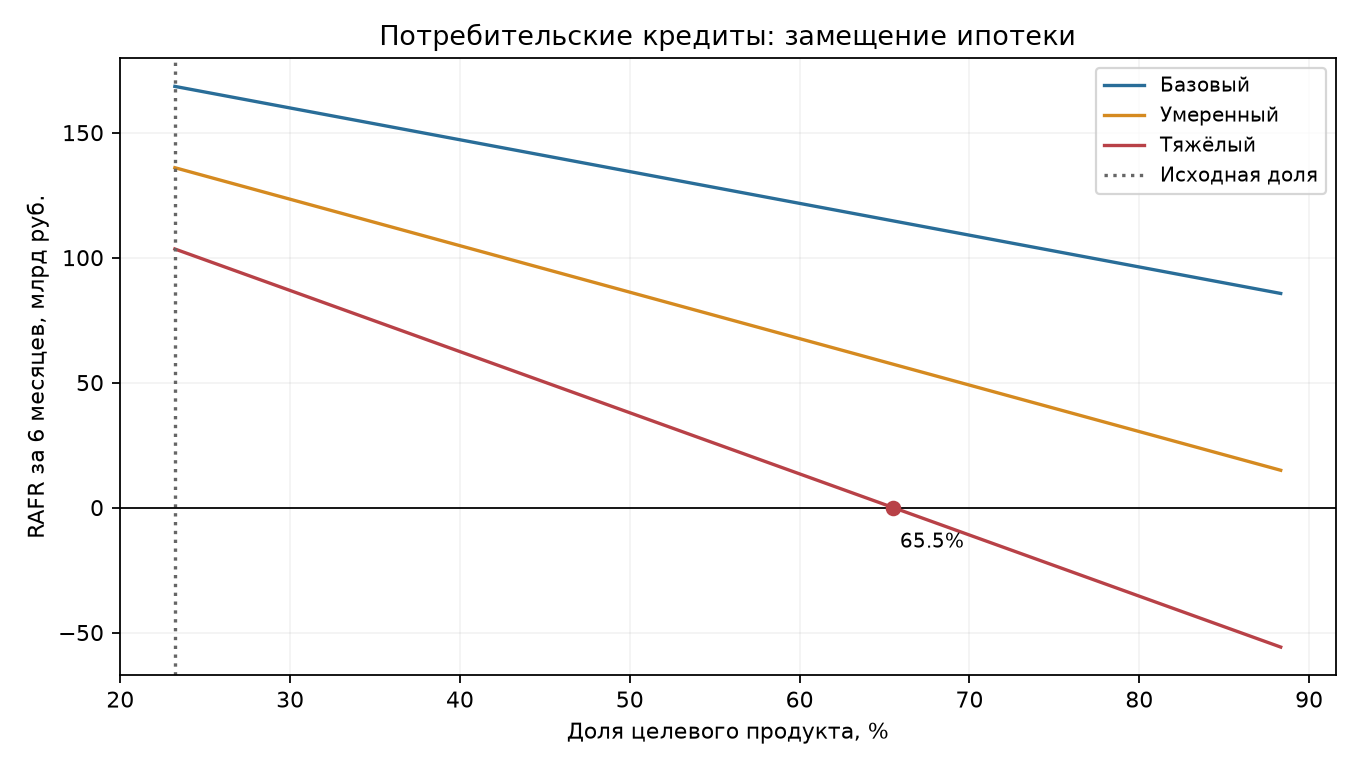

### Автокредиты

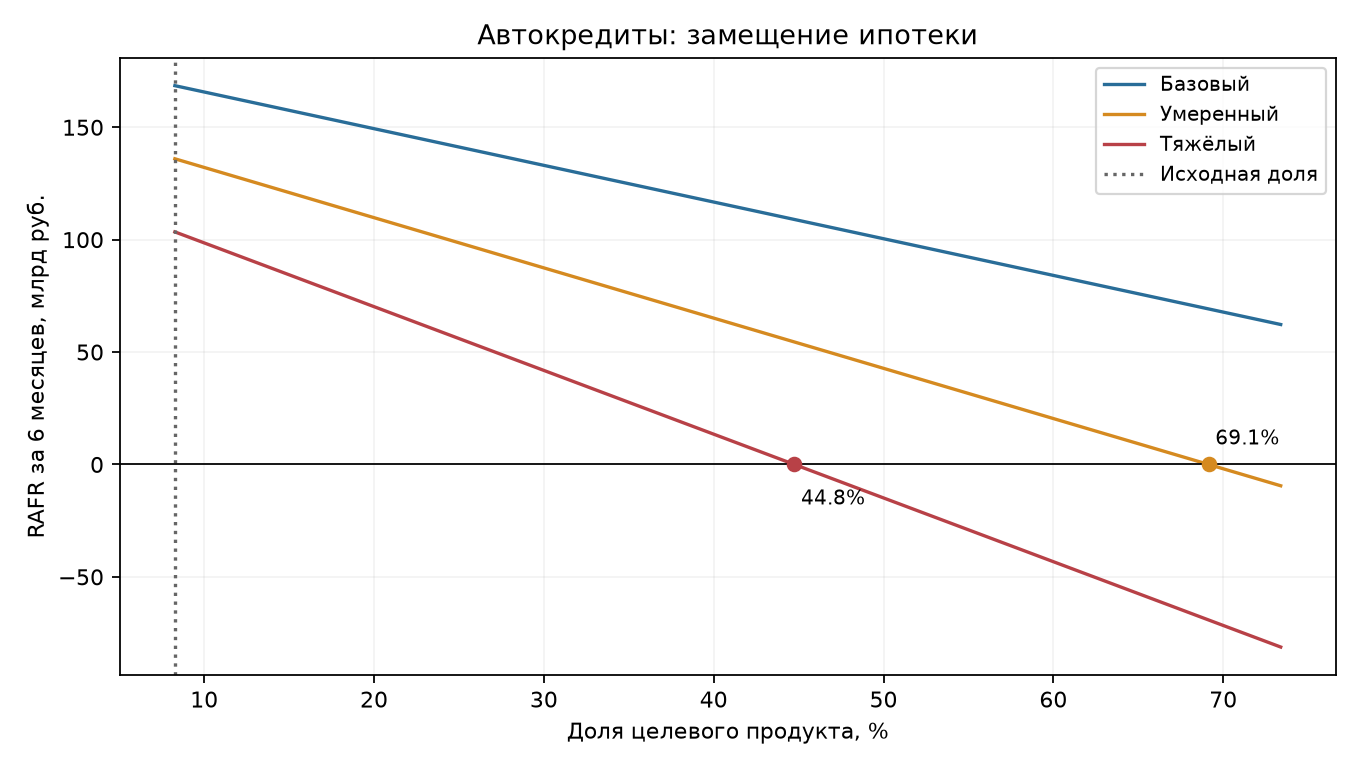

### Кредитные карты

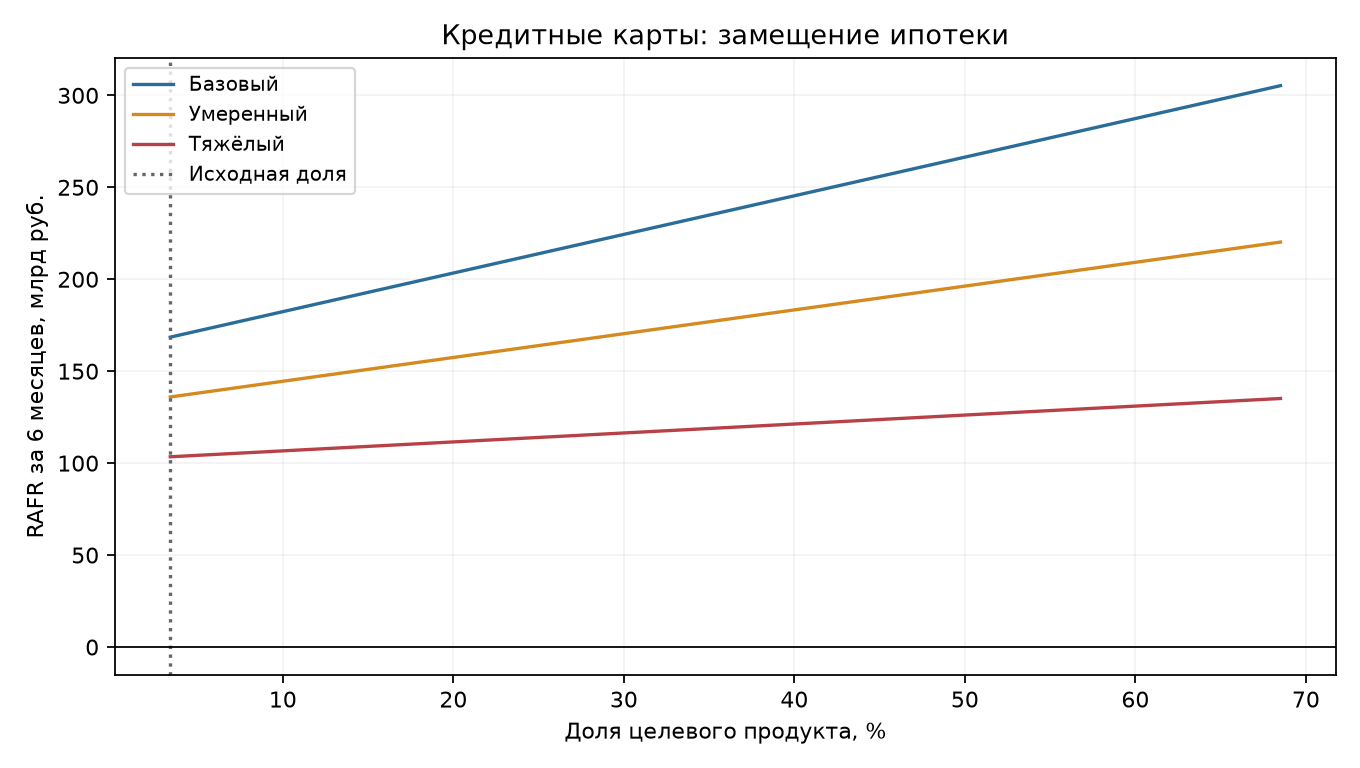

In [5]:
for product in sm.RISKIER_PRODUCTS:
    display(Markdown('### ' + sm.PRODUCT_LABELS[product]))
    display(Image(filename=str(root / cfg.output_dir / 'figures' / f'{product.lower()}_share_sensitivity.png')))


## Устойчивость к спецификации ипотечной и карточной ставки

Ипотечная чувствительность меняет только pricing от 9,0 до 17,8%; потери и структура фиксированы. Карточная чувствительность условно снижает исходную внешнюю ставку на 5, 10 и 15 п.п. Это диапазон MODEL ASSUMPTION, а не оценка фактической карточной доходности.

| Ипотечная ставка   |   Base RAFR, млрд руб. |   Потери, млрд руб. |
|:-------------------|-----------------------:|--------------------:|
| 9.00%              |                -19.798 |              65.053 |
| 17.80%             |                168.514 |              65.053 |

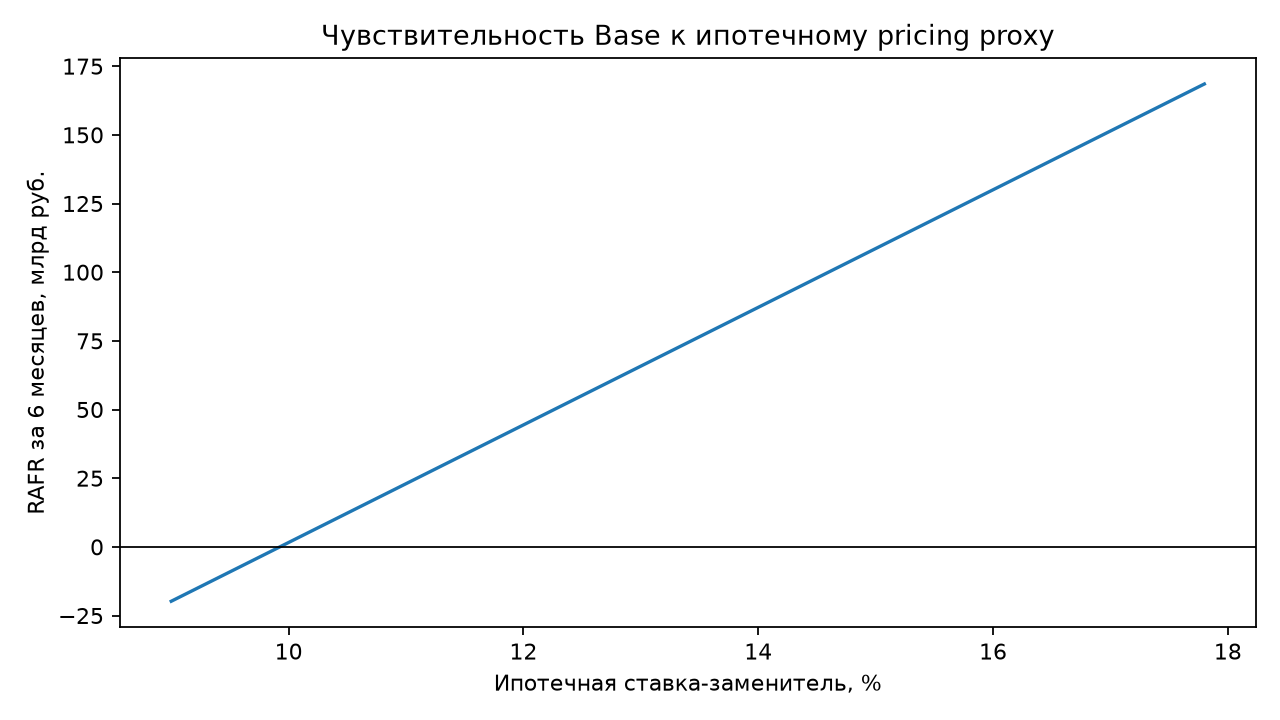

| Сценарий   | Карточная ставка   |   ΔRAFR на +1 п.п. | Критическая доля   | Статус                            |
|:-----------|:-------------------|-------------------:|:-------------------|:----------------------------------|
| Базовый    | 31.20%             |              2.100 | NA                 | Нет порога в допустимом диапазоне |
| Базовый    | 26.20%             |              0.457 | NA                 | Нет порога в допустимом диапазоне |
| Базовый    | 21.20%             |             -1.186 | NA                 | Нет порога в допустимом диапазоне |
| Базовый    | 16.20%             |             -2.830 | 57.03%             | Порог существует                  |
| Умеренный  | 31.20%             |              1.293 | NA                 | Нет порога в допустимом диапазоне |
| Умеренный  | 26.20%             |             -0.350 | NA                 | Нет порога в допустимом диапазоне |
| Умеренный  | 21.20%             |             -1.993 | 66.03%             | Порог существует                  |
| Умеренный  | 16.20%             |             -3.636 | 36.19%             | Порог существует                  |
| Тяжёлый    | 31.20%             |              0.487 | NA                 | Нет порога в допустимом диапазоне |
| Тяжёлый    | 26.20%             |             -1.157 | NA                 | Нет порога в допустимом диапазоне |
| Тяжёлый    | 21.20%             |             -2.800 | 36.36%             | Порог существует                  |
| Тяжёлый    | 16.20%             |             -4.443 | 22.91%             | Порог существует                  |

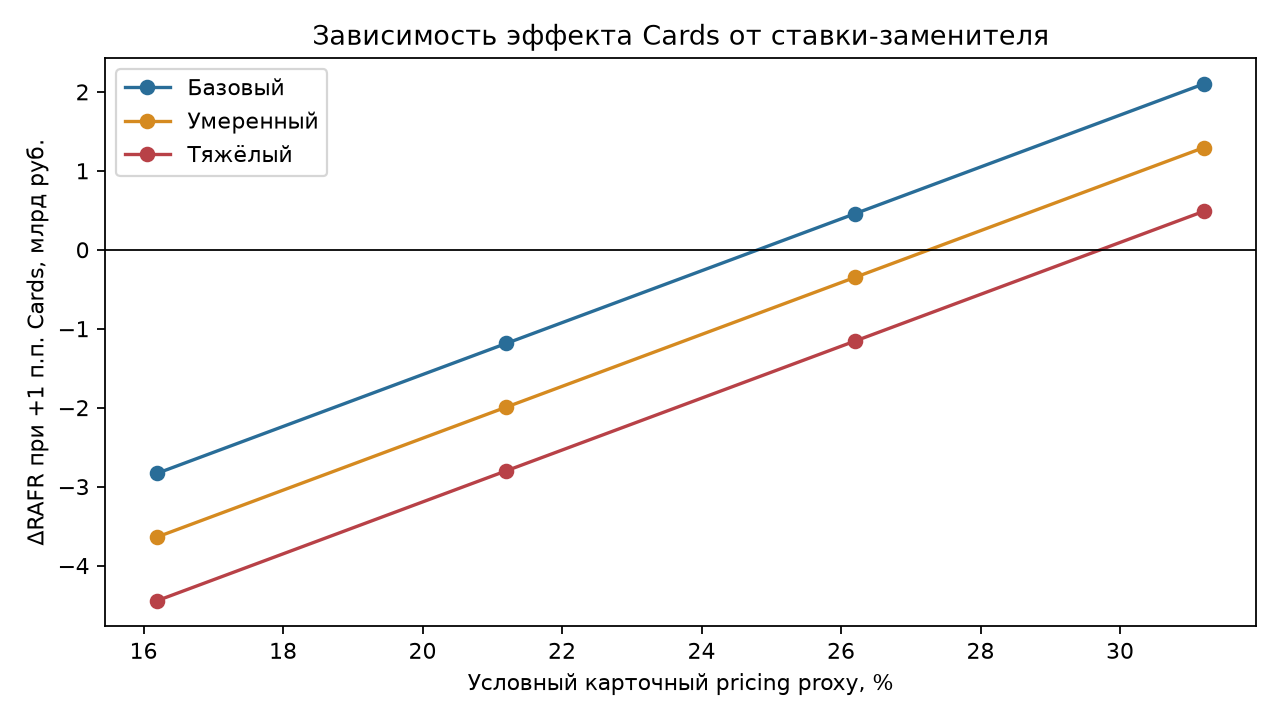

In [6]:
mortgage = pd.read_csv(files['mortgage_pricing_sensitivity'])
cards = pd.read_csv(files['card_pricing_sensitivity'])
display(Markdown(sm.presentation_table(mortgage, rates=['mortgage_pricing'],
    labels={'mortgage_pricing': 'Ипотечная ставка', 'raf_result_bn': 'Base RAFR, млрд руб.',
            'credit_loss_bn': 'Потери, млрд руб.'})))
display(Image(filename=str(root / cfg.output_dir / 'figures/mortgage_pricing_sensitivity.png')))
display(Markdown(sm.presentation_table(
    cards[['scenario', 'card_pricing', 'delta_raf_result_per_1pp', 'critical_share', 'status']],
    rates=['card_pricing', 'critical_share'],
    labels={'scenario': 'Сценарий', 'card_pricing': 'Карточная ставка',
            'delta_raf_result_per_1pp': 'ΔRAFR на +1 п.п.', 'critical_share': 'Критическая доля', 'status': 'Статус'})))
display(Image(filename=str(root / cfg.output_dir / 'figures/card_pricing_sensitivity.png')))


## Проверки и происхождение данных

FACT — только независимо сверенные показатели первоисточника. Компоненты ВТБ имеют статус PENDING: арифметическая сверка не заменяет постраничное сопоставление. MARKET PROXY — внешние ставки ЦБ, SYNTHETIC — модельный портфель, MODEL ASSUMPTION — множители стресса и диапазон карточной чувствительности, CALCULATED — CC, CRAS, RAFR, потери и пороги.

Отдельно проверяются формулы, неизменность общей экспозиции, фиксированные две доли, согласованность аналитики и сетки, попадание порогов в допустимый диапазон.

In [7]:
assert not qa.status.eq('FAIL').any()
display(qa.groupby('status').size().rename('Число проверок').to_frame())
display(Markdown('Сверка продуктовых компонентов ВТБ: **' + cfg.source_qa['vtb_product_components'] + '**.'))


,Число проверок
status,
PASS,51
PENDING,1


Сверка продуктовых компонентов ВТБ: **PENDING**.

## Интерпретация и ограничения

Знак изменения RAFR определяется разностью CRAS выбранного продукта и ипотеки. Дополнительные кредитные потери могут сопровождаться как снижением, так и ростом RAFR. Именно сочетание этих двух эффектов и допустимых порогов отвечает на исследовательский вопрос.

Карточный proxy — внешняя краткосрочная розничная ставка, которая не отражает льготный период, использование лимита, interchange (межбанковское вознаграждение), комиссии и соотношение клиентов с полным погашением долга и переносом остатка. При отсутствии порога нельзя делать вывод о допустимости любой доли карт; результат условен относительно ставки-заменителя.

RAFR не является прибылью ВТБ; комиссии, операционные расходы, налоги и капитал исключены. RWA и RAROC не рассчитываются. Шесть дат и изменение периметра из-за Почта Банка ограничивают интерпретацию.

Источник ставок: [Банк России, июнь 2026](https://www.cbr.ru/statistics/bank_sector/int_rat/0626/). Статус сверки компонентов: [SOURCE_QA_2026H1.md](../other/SOURCE_QA_2026H1.md).